<a href="https://colab.research.google.com/github/Ammar-muz/NorthStar-Analytics/blob/main/northstar_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

customers = pd.read_csv("customers.csv")
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
orders = pd.read_csv("orders.csv")
incidents = pd.read_csv("incidents.csv")
app_events = pd.read_csv("app_events.csv")

In [3]:
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [4]:
customers.columns

Index(['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date',
       'loyalty_score', 'app_engagement_score', 'preferred_channel',
       'account_status'],
      dtype='object')

In [5]:
deliveries.columns

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

In [6]:
complaints.columns

Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')

In [7]:
deliveries['delivery_status'].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


In [8]:
complaints['complaint_type'].value_counts()

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


In [9]:
customers.columns
deliveries.columns
complaints.columns

Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')

In [10]:
orders.columns
deliveries.columns
customers.columns

Index(['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date',
       'loyalty_score', 'app_engagement_score', 'preferred_channel',
       'account_status'],
      dtype='object')

In [11]:
orders_customers = pd.merge(orders, customers, on='customer_id', how='inner')
orders_customers.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,24,South,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0,20,WEST,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0,42,north,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1,50,NORTH,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0,23,SOUTH,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active


In [12]:
full_data = pd.merge(deliveries, orders_customers, on='order_id', how='inner')
full_data.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,booking_channel,special_handling_flag,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,Web,0,74,East,Consumer,2024-02-18 04:31:00,79.7,64.9,App,Active
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,App,1,50,NORTH,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,Web,0,26,NORTH,Enterprise,2025-03-02 00:55:00,67.6,49.6,App,Dormant
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,App,0,49,RiverSide,Consumer,2024-11-30 06:56:00,65.9,78.2,Phone,Active
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,App,0,47,South,Consumer,2024-11-15 02:59:00,66.9,76.6,App,Active


In [13]:
final_data = pd.merge(full_data, complaints, on='customer_id', how='left')
final_data.head()

,delivery_id,order_id_x,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,account_status,complaint_id,order_id_y,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,Active,CP0253,O00012,AppIssue,App,Medium,2024-01-25 12:45:00,Resolved,13.0,22.73
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,Dormant,CP0114,O01104,MissedPickup,Phone,Medium,2024-09-27 16:27:00,Open,5.0,0.00
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,Dormant,CP0133,O01104,Delay,App,High,2024-09-21 16:27:00,Open,15.0,38.76
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
final_data[['delivery_status', 'complaint_type']].head()

,delivery_status,complaint_type
0,Failed,AppIssue
1,OnTime,NaN
2,OnTime,MissedPickup
3,OnTime,Delay
4,Delayed,NaN


In [15]:
final_data.groupby('delivery_status')['complaint_type'].count()

,complaint_type
delivery_status,
Delayed,138
Failed,94
OnTime,437


<Axes: xlabel='delivery_status'>

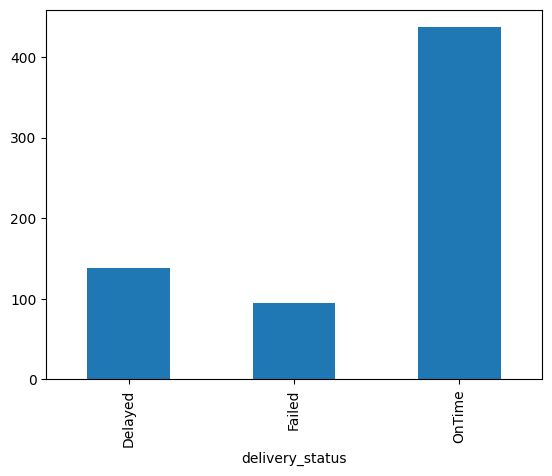

In [16]:
final_data.groupby('delivery_status')['complaint_type'].count().plot(kind='bar')

In [17]:
final_data.columns

Index(['delivery_id', 'order_id_x', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost', 'customer_id', 'service_type',
       'order_created_at', 'promised_window_hours', 'pickup_zone',
       'dropoff_zone', 'priority_level', 'order_value', 'booking_channel',
       'special_handling_flag', 'age', 'home_zone', 'customer_type',
       'signup_date', 'loyalty_score', 'app_engagement_score',
       'preferred_channel', 'account_status', 'complaint_id', 'order_id_y',
       'complaint_type', 'channel', 'severity', 'created_at', 'status',
       'resolution_days', 'compensation_amount'],
      dtype='object')

In [18]:
final_data.groupby('hub_id')['delivery_status'].value_counts().unstack(fill_value=0)

delivery_status,Delayed,Failed,OnTime
hub_id,,,
H01,31,19,107
H02,34,12,78
H03,30,12,104
H04,34,22,98
H05,32,26,84
H06,31,20,76
H07,29,15,95
H08,27,35,106


<Axes: xlabel='hub_id'>

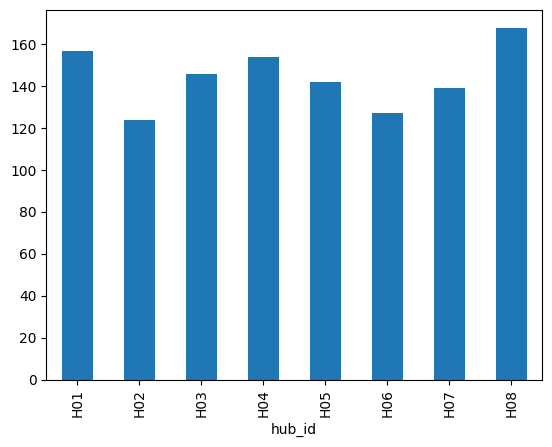

In [19]:
final_data.groupby('hub_id')['delivery_status'].count().plot(kind='bar')

In [20]:
final_data.groupby('pickup_zone')['delivery_status'].value_counts().unstack(fill_value=0)

delivery_status,Delayed,Failed,OnTime
pickup_zone,,,
AIRPORT,18,5,35
Airport,22,10,49
CENTRAL,22,12,37
Central,14,12,43
Ctr,25,13,38
EAST,16,16,62
East,20,9,64
NORTH,17,10,40
North,6,9,28


In [21]:
final_data['pickup_zone'] = final_data['pickup_zone'].str.lower().str.strip()

In [22]:
final_data.groupby('delivery_status')['route_distance_km'].mean()

,route_distance_km
delivery_status,
Delayed,14.664637
Failed,13.172919
OnTime,13.681872


In [23]:
final_data.groupby('delivery_status')['manual_route_override_count'].mean()

,manual_route_override_count
delivery_status,
Delayed,1.088710
Failed,1.049689
OnTime,0.925134


In [24]:
final_data.groupby('driver_id')['delivery_status'].value_counts()

driver_id  delivery_status
D001       OnTime             5
           Delayed            1
           Failed             1
D002       OnTime             5
           Delayed            2
                             ..
D168       Failed             1
D169       OnTime             2
D170       Delayed            2
           Failed             2
           OnTime             1
Name: count, Length: 368, dtype: int64

In [25]:
final_data.groupby('vehicle_id')['delivery_status'].value_counts()

vehicle_id  delivery_status
V001        OnTime              7
            Delayed             3
V002        Failed              4
            Delayed             2
            OnTime              2
                               ..
V119        OnTime              7
            Delayed             6
            Failed              1
V120        OnTime             14
            Delayed             1
Name: count, Length: 279, dtype: int64

In [26]:
complaints['severity'].value_counts()

,count
severity,
Medium,172
High,77
Low,71


In [27]:
incidents['incident_type'].value_counts()

,count
incident_type,
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


In [28]:
app_events.head()

,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
3,AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
4,AE00005,C0506,NaN,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1


In [29]:
final_data.groupby('hub_id')['fuel_or_charge_cost'].mean()

,fuel_or_charge_cost
hub_id,
H01,12.891274
H02,12.541532
H03,12.674932
H04,13.144221
H05,13.603873
H06,13.088031
H07,12.898993
H08,11.610000


In [30]:
final_data['dispatch_time'] = pd.to_datetime(final_data['dispatch_time'])
final_data['delivery_completed_at'] = pd.to_datetime(final_data['delivery_completed_at'])

final_data['delay_time'] = (final_data['delivery_completed_at'] - final_data['dispatch_time']).dt.total_seconds() / 60

Please ensure you have run all preceding cells that load and merge the data into `final_data` and calculate `delay_time` before executing the following cells, especially if you have restarted the kernel.

In [31]:
final_data['delay_time'].mean()

np.float64(575.9728549668864)

In [32]:
import numpy as np

np.mean(final_data['delay_time'])
np.std(final_data['delay_time'])

519.8464921200961

In [33]:
import numpy as np

print("Mean delay:         ", np.mean(final_data['delay_time']))
print("Std deviation:      ", np.std(final_data['delay_time']))
print("25th percentile:    ", np.percentile(final_data['delay_time'].dropna(), 25))
print("75th percentile:    ", np.percentile(final_data['delay_time'].dropna(), 75))
print("Max delay:          ", np.max(final_data['delay_time'].dropna()))
print("Min delay:          ", np.min(final_data['delay_time'].dropna()))

Mean delay:          575.9728549668864
Std deviation:       519.8464921200961
25th percentile:     175.1563582375
75th percentile:     880.0705411458333
Max delay:           2607.4150918833334
Min delay:           -132.86863208333332


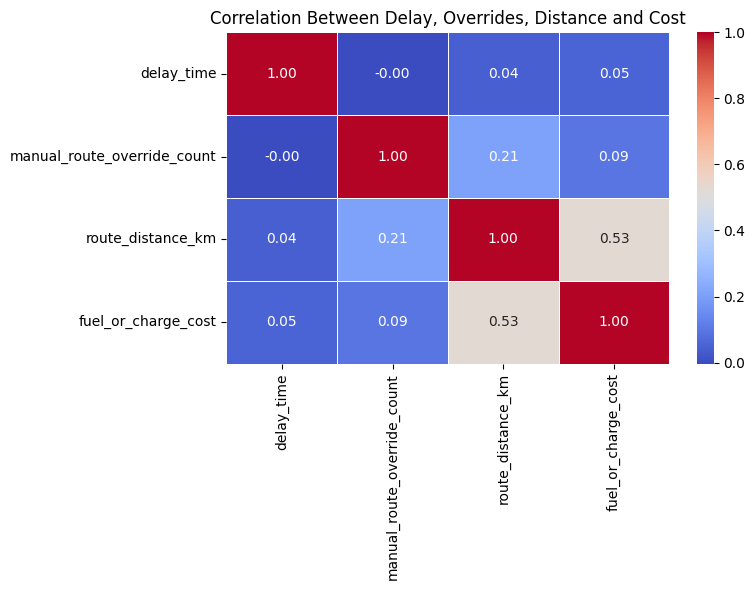

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = final_data[['delay_time', 'manual_route_override_count', 'route_distance_km', 'fuel_or_charge_cost']].dropna()

plt.figure(figsize=(8,6))
sns.heatmap(corr_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Delay, Overrides, Distance and Cost')
plt.tight_layout()
plt.show()

In [35]:
final_data['dispatch_time'] = pd.to_datetime(final_data['dispatch_time'])
final_data['delivery_completed_at'] = pd.to_datetime(final_data['delivery_completed_at'])
final_data['delay_time'] = (final_data['delivery_completed_at'] - final_data['dispatch_time']).dt.total_seconds() / 60

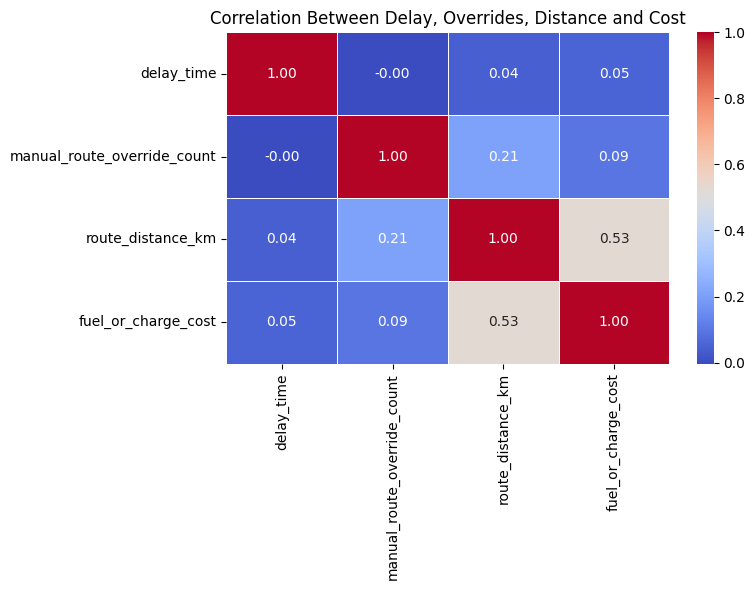

In [36]:
# CORRECT column names from real dataset
corr_cols = final_data[['delay_time', 'manual_route_override_count', 'route_distance_km', 'fuel_or_charge_cost']].dropna()

plt.figure(figsize=(8,6))
sns.heatmap(corr_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Delay, Overrides, Distance and Cost')
plt.tight_layout()
plt.show()

delivery_status
Delayed    3.145892
Failed     3.033625
OnTime     4.286730
Name: customer_rating_post_delivery, dtype: float64


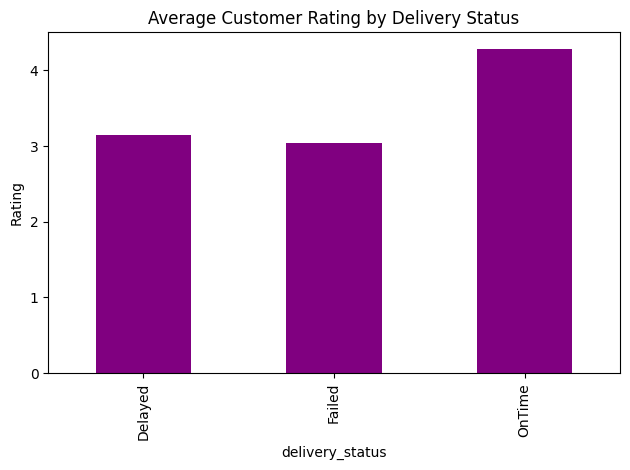

In [37]:
rating_by_status = final_data.groupby('delivery_status')['customer_rating_post_delivery'].mean()
print(rating_by_status)

rating_by_status.plot(kind='bar', color='purple')
plt.title('Average Customer Rating by Delivery Status')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

proof_of_completion_missing
0    1061
1      96
Name: count, dtype: int64


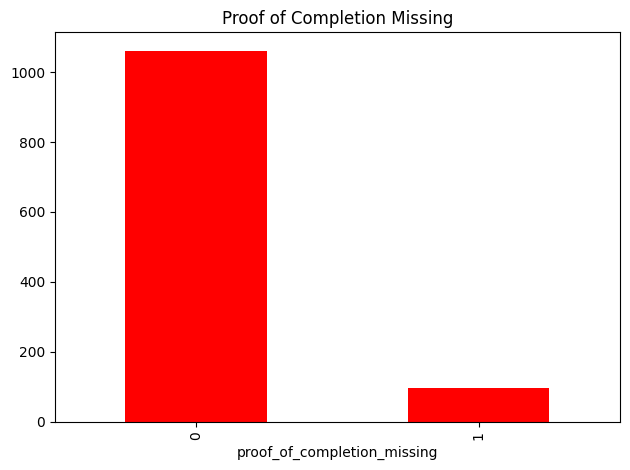

In [38]:
missing_proof = final_data['proof_of_completion_missing'].value_counts()
print(missing_proof)

missing_proof.plot(kind='bar', color='red')
plt.title('Proof of Completion Missing')
plt.tight_layout()
plt.show()

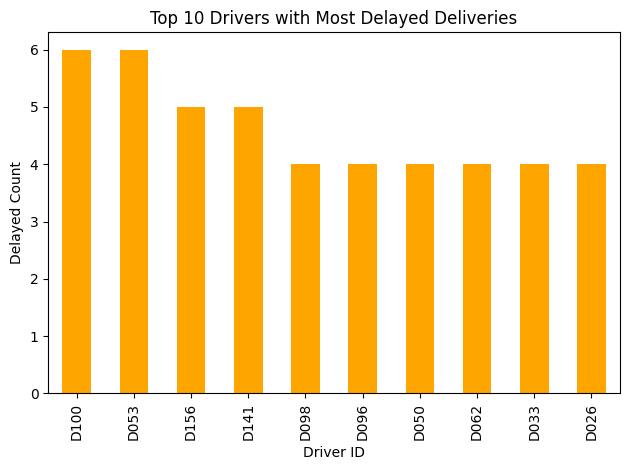

In [40]:
driver_perf = final_data.groupby('driver_id')['delivery_status'].value_counts().unstack().fillna(0)
driver_perf['Delayed'].sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Drivers with Most Delayed Deliveries')
plt.xlabel('Driver ID')
plt.ylabel('Delayed Count')
plt.tight_layout()
plt.show()

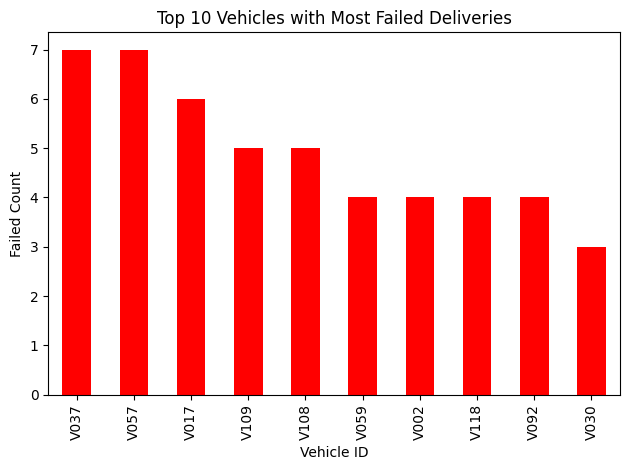

In [42]:
vehicle_perf = final_data.groupby('vehicle_id')['delivery_status'].value_counts().unstack().fillna(0)
vehicle_perf['Failed'].sort_values(ascending=False).head(10).plot(kind='bar', color='red')
plt.title('Top 10 Vehicles with Most Failed Deliveries')
plt.xlabel('Vehicle ID')
plt.ylabel('Failed Count')
plt.tight_layout()
plt.show()

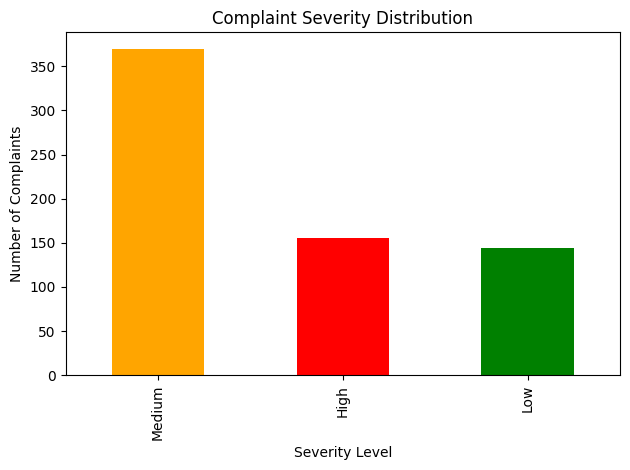

In [43]:
final_data['severity'].value_counts().plot(kind='bar', color=['orange','red','green'])
plt.title('Complaint Severity Distribution')
plt.xlabel('Severity Level')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

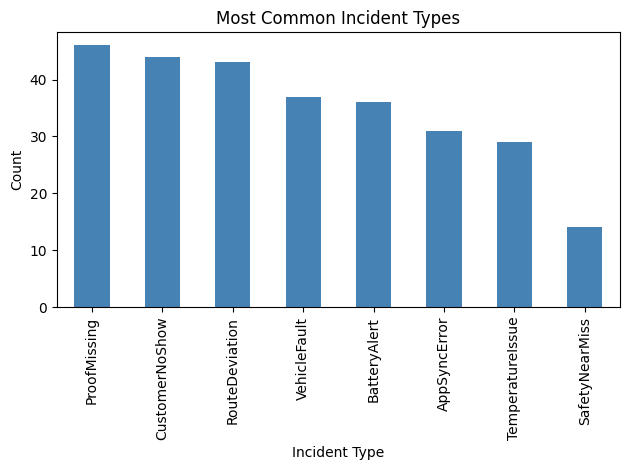

In [44]:
incidents = pd.read_csv('incidents.csv')
incidents['incident_type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Most Common Incident Types')
plt.xlabel('Incident Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Shape: (640, 10)
  event_id customer_id order_id      event_timestamp    event_type session_id  \
0  AE00001       C0488      NaN  2024-08-09 03:25:00   eta_refresh     S19847   
1  AE00002       C0595   O00950  2024-02-13 22:29:00  search_route     S32766   
2  AE00003       C0494   O00170  2025-08-11 09:29:00   chat_opened     S99516   
3  AE00004       C0407   O00756  2025-08-23 17:38:00   eta_refresh     S41236   
4  AE00005       C0506      NaN  2024-05-29 10:33:00  search_route     S12030   

  device_type zone_context  api_latency_ms  success_flag  
0     Android        north             301             1  
1     Android        SOUTH              60             1  
2         iOS      Airport            1118             1  
3         iOS      CENTRAL             442             1  
4         iOS        north              60             1  


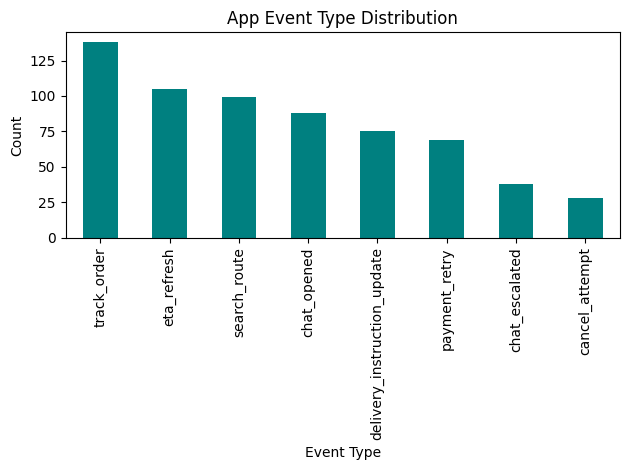

In [45]:
app_events = pd.read_csv('app_events.csv')
print("Shape:", app_events.shape)
print(app_events.head())

app_events['event_type'].value_counts().plot(kind='bar', color='teal')
plt.title('App Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

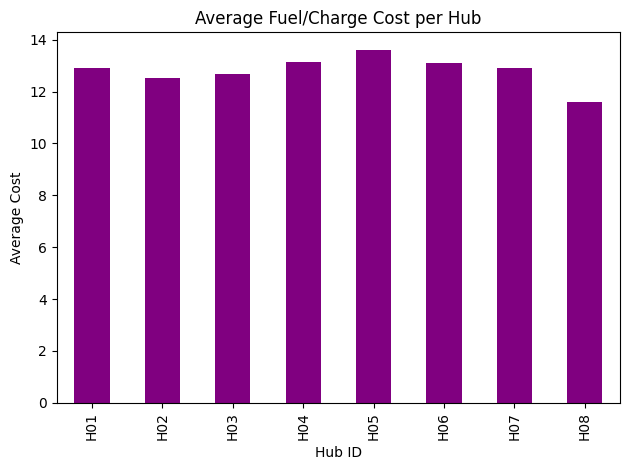

In [46]:
final_data.groupby('hub_id')['fuel_or_charge_cost'].mean().plot(kind='bar', color='purple')
plt.title('Average Fuel/Charge Cost per Hub')
plt.xlabel('Hub ID')
plt.ylabel('Average Cost')
plt.tight_layout()
plt.show()

In [47]:
corr_matrix = final_data[['delay_time', 'manual_route_override_count', 'route_distance_km', 'fuel_or_charge_cost']].dropna().corr()

print(corr_matrix.round(2))
print(f"\nDelay vs Distance:  {corr_matrix.loc['delay_time','route_distance_km']:.2f}")
print(f"Delay vs Overrides: {corr_matrix.loc['delay_time','manual_route_override_count']:.2f}")
print(f"Delay vs Cost:      {corr_matrix.loc['delay_time','fuel_or_charge_cost']:.2f}")

                             delay_time  manual_route_override_count  \
delay_time                         1.00                        -0.00   
manual_route_override_count       -0.00                         1.00   
route_distance_km                  0.04                         0.21   
fuel_or_charge_cost                0.05                         0.09   

                             route_distance_km  fuel_or_charge_cost  
delay_time                                0.04                 0.05  
manual_route_override_count               0.21                 0.09  
route_distance_km                         1.00                 0.53  
fuel_or_charge_cost                       0.53                 1.00  

Delay vs Distance:  0.04
Delay vs Overrides: -0.00
Delay vs Cost:      0.05
